**INTRODUCTION**

The EduRead Digital Library platform generates large volumes of transactional and customer data that can provide valuable insights into business performance and user behavior. To support data-driven decision-making, a data mart was developed to consolidate key information related to orders, revenue, customers, books, authors, and payment methods. This analysis leverages the EduRead data mart to examine platform growth, purchasing patterns, content performance, payment behavior, and customer retention.

The objective of this report is to answer several strategic business questions relevant to different stakeholders across the organization, including leadership, finance, partnerships, product management, customer success, and operations teams. By analyzing revenue trends, order volume, author and genre performance, payment method usage, and customer purchasing behavior, the report identifies actionable insights that can guide marketing strategies, product improvements, partnership decisions, and customer retention initiatives for the EduRead platform.

### Libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import geopandas as gpd
import pyodbc
import seaborn as sns
sns.set_style("whitegrid")

### First, we'll create a connection ("engine") to connect to the local instance of SQL Server. 

In [8]:
# Define connection parameters
server = "." # local SQL Server
database = "EduReadDataMart"
driver = "ODBC Driver 17 for SQL Server"
# Create SQLAlchemy engine
connection_string = f"mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver={driver}"
engine = create_engine(connection_string)

print("Connection created successfully!")



Connection created successfully!


### Test Query

In [10]:

query = "SELECT TOP 5 * FROM DimStudent"

with engine.connect() as conn:
    df = pd.read_sql(text(query), conn)
df.head()

,Student_SK,Student_BK,FirstName,LastName,FLName,Age,Gender,City,State,Address
0,651,1,Aiden,Brown,Aiden Brown,29,Female,New York,NY,9684 Harbor Point St
1,652,2,Sophia,Davis,Sophia Davis,37,Male,Miami,FL,116 Lakeview Way
2,653,3,Emma,Miller,Emma Miller,35,Female,"Suite 487""","Boston,MA","""7537 Broadstone Ave"
3,654,4,Noah,Moore,Noah Moore,17,Female,"Suite 975""","Seattle,WA","""760 Juniper Ln"
4,655,5,Amelia,Ramirez,Amelia Ramirez,29,Male,Chicago,IL,3442 Willow Creek Ave


## Total Monthly Revenue Trends

In [11]:

q1_sql = """
SELECT
    dd.Year,
    dd.Quarter,
    dd.Month,
    dd.MonthName,
    COUNT(DISTINCT fs.Order_BK) AS TotalOrders,
    SUM(fs.NetSalesAmount)      AS TotalRevenue
FROM FactSales fs
JOIN DimDate dd
    ON fs.SalesDate = dd.Date_SK
GROUP BY dd.Year, dd.Quarter, dd.Month, dd.MonthName
ORDER BY dd.Year, dd.Month;
"""

with engine.connect() as conn:
    q1 = pd.read_sql(text(q1_sql), conn)

q1.head()

,Year,Quarter,Month,MonthName,TotalOrders,TotalRevenue
0,2024,1,1,January,91,3162.58
1,2024,1,2,February,57,1991.45
2,2024,1,3,March,82,3145.94
3,2024,2,4,April,69,2453.21
4,2024,2,5,May,84,2779.22


In [12]:
q1["YearMonth"] = pd.to_datetime(
    q1["Year"].astype(str) + "-" + q1["Month"].astype(str) + "-01"
)

q1.tail()

,Year,Quarter,Month,MonthName,TotalOrders,TotalRevenue,YearMonth
19,2025,3,8,August,101,3914.54,2025-08-01
20,2025,3,9,September,110,4066.95,2025-09-01
21,2025,4,10,October,89,3553.53,2025-10-01
22,2025,4,11,November,109,3644.78,2025-11-01
23,2025,4,12,December,119,4057.36,2025-12-01


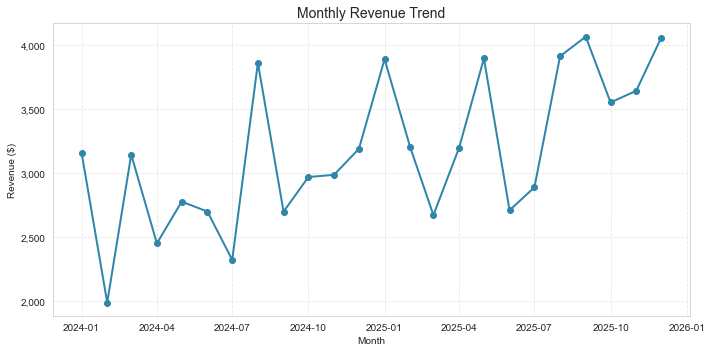

In [56]:
plt.figure(figsize=(10,5))

plt.plot(
    q1["YearMonth"],
    q1["TotalRevenue"],
    marker="o",
    color="#2E86AB",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

# Format currency
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Insight**
- Revenue fluctuates throughout the year, with several noticeable spikes that suggest seasonal purchasing behavior on EduRead Platform. Toward the latter months, revenue levels appear higher, indicating potential growth in customer engament and transaction activity over time.

**Recommendation**
- Align marketing campaigns, content promotions and partnership launches with peak purchasing periods to maximize revenue opportunities. Targeted engagement initiatives during slower months could help stabilize demand and improve revenue consistency

## Annual Revenue Growth (Total Revenue by Year)

In [14]:
q1_year = """
SELECT
    dd.Year,
    COUNT(DISTINCT fs.Order_BK) AS TotalOrders,
    SUM(fs.NetSalesAmount) AS TotalRevenue
FROM FactSales fs
JOIN DimDate dd
    ON fs.SalesDate = dd.Date_SK
GROUP BY dd.Year
ORDER BY dd.Year
"""

with engine.connect() as conn:
    revenue_year = pd.read_sql(text(q1_year), conn)

revenue_year

,Year,TotalOrders,TotalRevenue
0,2024,925,34273.08
1,2025,1125,41704.28


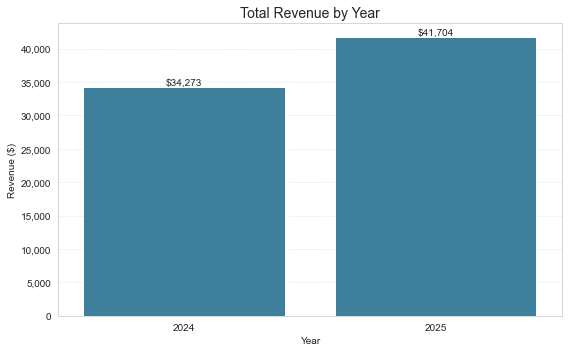

In [63]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=revenue_year,
    x="Year",
    y="TotalRevenue",
    color="#2E86AB"
)

plt.title("Total Revenue by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Revenue ($)")


# Format currency
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:,.0f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insight**
- Annual revenue increased from $34,273 in 2024 to $41,704 in 2025, representing an approximate 21.7% year-over-year growth.This indicates strong improvement in platform performance and suggests increasing user engagement and purchasing activity on the EduRead digital library

**Recommendation**
- EduRead should continue expanding high-performing content categories and strengthening partnerships with top authors and publishers. Additionally, targeted marketing campaigns and personalized recommendations could further drive customer engagement and support continued revenue growth

## Top Author by Revenue

In [23]:
q_authors = """
SELECT
    db.Author,
    SUM(fs.NetSalesAmount) AS Revenue,
    COUNT(DISTINCT fs.Order_BK) AS Orders
FROM FactSales fs
JOIN DimBook db
    ON fs.Book_SK = db.Book_SK
GROUP BY db.Author
ORDER BY Revenue DESC
"""

with engine.connect() as conn:
    author_revenue = pd.read_sql(text(q_authors), conn)

author_revenue.head(10)

,Author,Revenue,Orders
0,Isabella Garcia,2702.06,106
1,Noah Garcia,2373.80,70
2,Benjamin Garcia,1995.70,66
3,Sophia Anderson,1946.34,63
4,Sophia Smith,1814.50,64
5,Ella Jackson,1706.06,46
6,Nora Martin,1702.24,67
7,Harper Gonzalez,1700.55,48
8,Sophia Taylor,1466.67,49
9,Ava Williams,1417.18,40


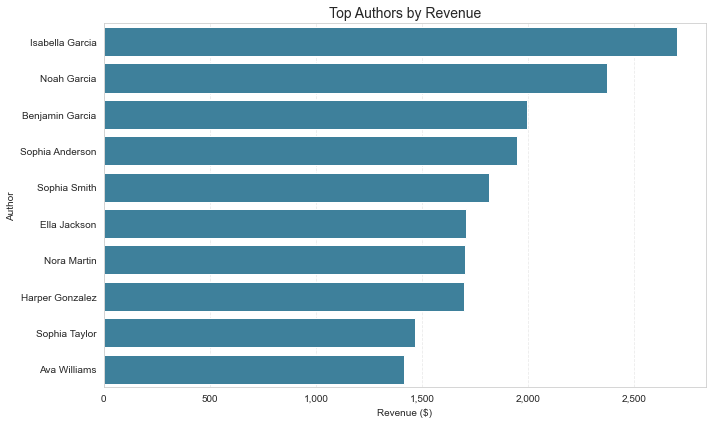

In [65]:
plt.figure(figsize=(10,6))

top_authors = author_revenue.head(10)

sns.barplot(
    data=top_authors,
    y="Author",
    x="Revenue",
    color="#2E86AB"
)

plt.title("Top Authors by Revenue", fontsize=14)
plt.xlabel("Revenue ($)")
plt.ylabel("Author")

# Format currency
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insight**
- Revenue contributions are concentrated among a small group of authors, with Isabella Garcia generating the highest revenue, followed by Noah Garcia and Benjamin Garcia. This concentration indicates that a limited number of authors play a significant role in driving overall platform sales

**Recommendation**
- EduRead should prioritize partnerships and promotional efforts with high-performing authors to maximize revenue potential. Highlighting these authors through featured content, curated reading lists, and targeted marketing campaigns could further increase customer engagement and sales

## Revenue Contribution by Book Genre

In [27]:
q_genres = """
SELECT
    db.Genre,
    SUM(fs.NetSalesAmount) AS Revenue,
    COUNT(DISTINCT fs.Order_BK) AS Orders
FROM FactSales fs
JOIN DimBook db
    ON fs.Book_SK = db.Book_SK
GROUP BY db.Genre
ORDER BY Revenue DESC
"""
with engine.connect() as conn:
    genre_revenue = pd.read_sql(text(q_genres), conn)

genre_revenue

,Genre,Revenue,Orders
0,History,10500.95,410
1,Mystery,10124.11,304
2,Sci-Fi,8364.07,372
3,Fiction,7873.47,331
4,Self-Help,7236.44,279
5,Romance,7038.03,265
6,Nonfiction,6985.85,262
7,Business,6736.11,250
8,Fantasy,6672.90,243
9,Kids,4445.43,176


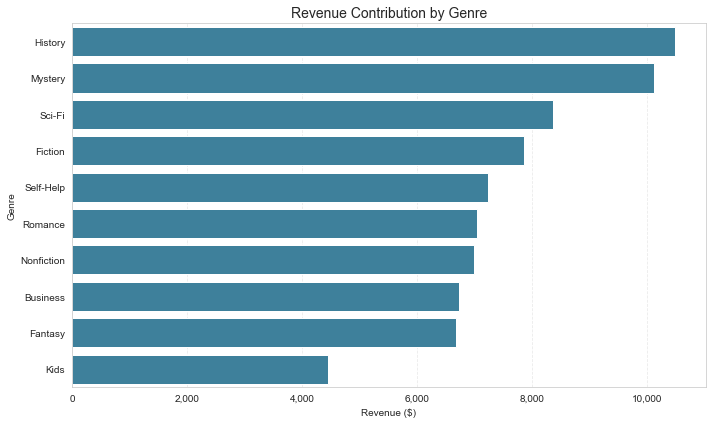

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_revenue,
    y="Genre",
    x="Revenue",
    color="#2E86AB"
)

plt.title("Revenue Contribution by Genre", fontsize=14)
plt.xlabel("Revenue ($)")
plt.ylabel("Genre")

# Format currency
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insight**
- Revenue distribution across genres shows that **History** and **Mystery** titles generate the highest revenue on the EduRead platform, followed by Sci-Fi and Fiction. This suggests that readers show stronger purchasing interest in certain subject areas, indicating clear demand patterns across the platform’s content catalog

**Recommendation**
- EduRead should prioritize expanding high-performing genres such as History, Mystery, and Sci-Fi through additional author partnerships and new content acquisitions. Promoting these genres through curated collections or targeted recommendations could further increase engagement and revenue

## Average Order Value by Year

In [30]:
q_aov = """
SELECT
    dd.Year,
    COUNT(DISTINCT fs.Order_BK) AS TotalOrders,
    SUM(fs.NetSalesAmount) AS TotalRevenue,
    SUM(fs.NetSalesAmount) / COUNT(DISTINCT fs.Order_BK) AS AvgOrderValue
FROM FactSales fs
JOIN DimDate dd
    ON fs.SalesDate = dd.Date_SK
GROUP BY dd.Year
ORDER BY dd.Year
"""
with engine.connect() as conn:
    aov_data = pd.read_sql(text(q_aov), conn)

aov_data

,Year,TotalOrders,TotalRevenue,AvgOrderValue
0,2024,925,34273.08,37.0519
1,2025,1125,41704.28,37.0704


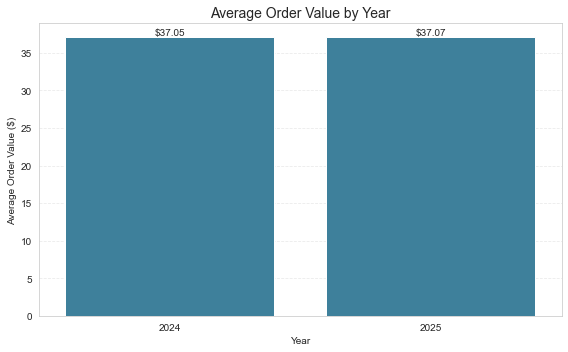

In [69]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=aov_data,
    x="Year",
    y="AvgOrderValue",
    color="#2E86AB"
)

plt.title("Average Order Value by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Order Value ($)")

# Format currency
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:,.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insights**
- The average order value remains relatively stable between 2024 and 2025, indicating that customers are spending a similar amount per transaction across both years. This suggests that the overall revenue growth observed in 2025 is likely driven by an increase in the number of orders rather than higher spending per order

**Recommendation**
- To increase revenue further, EduRead could explore strategies that encourage customers to purchase more items per transaction. Examples include bundle discounts, personalized recommendations, or curated reading collections that motivate users to add additional titles to their orders

## Revenue Contribution by Payment Method

In [34]:
q_payment = """
SELECT
    dpm.PaymentMethodName,
    COUNT(fs.PaymentLine_BK) AS NumberOfPayments,
    SUM(fs.PaymentAmount) AS TotalRevenue
FROM FactSales fs
JOIN DimPaymentMethod dpm
    ON fs.Payment_SK = dpm.Payment_SK
GROUP BY dpm.PaymentMethodName
ORDER BY TotalRevenue DESC
"""
with engine.connect() as conn:
    payment_data = pd.read_sql(text(q_payment), conn)

payment_data

,PaymentMethodName,NumberOfPayments,TotalRevenue
0,Discover,499,19544.25
1,MasterCard,449,18180.16
2,Visa,458,17541.91
3,Debit Card,468,17433.31
4,American Express,449,16390.26
5,Apple Pay,238,12030.20
6,PayPal,227,10894.47
7,Google Pay,215,9331.34


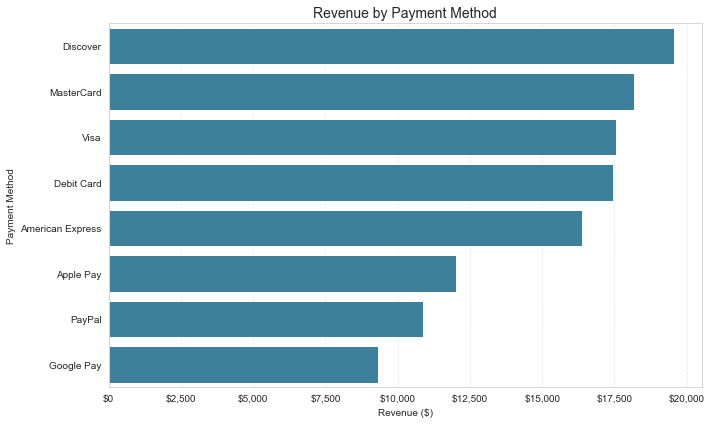

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_data,
    y="PaymentMethodName",
    x="TotalRevenue",
    color="#2E86AB"
)

plt.title("Revenue by Payment Method", fontsize=14)
plt.xlabel("Revenue ($)")
plt.ylabel("Payment Method")

# Format revenue axis
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insight**
- The chart shows that Discover, MasterCard, Visa, and Debit Card generate the largest share of platform revenue, indicating that traditional card-based payments remain the primary drivers of transactions on the EduRead platform. While digital wallet options such as Apple Pay, PayPal, and Google Pay contribute to revenue, their overall financial impact is noticeably lower.
This suggests that customers still rely heavily on conventional payment methods when purchasing books or subscriptions

**Recommendation**
- EduRead should ensure that the checkout experience remains optimized for major credit and debit card providers, as these methods account for the majority of revenue. At the same time, the platform may consider promoting digital wallet adoption through incentives or simplified mobile checkout flows, which could improve conversion rates for mobile users

## Usage Frequency by Payment Method

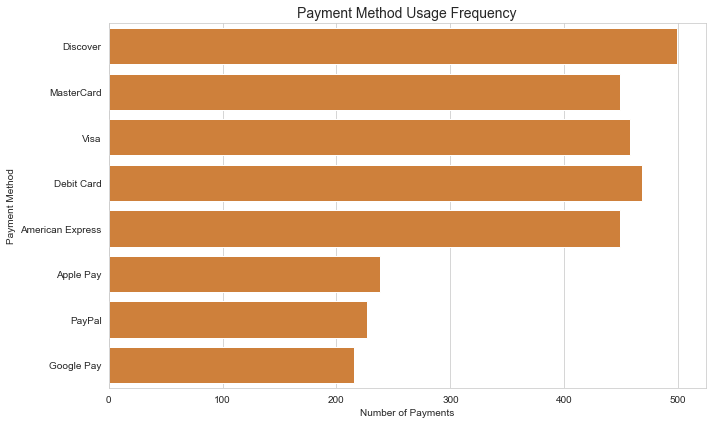

In [78]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_data,
    x="NumberOfPayments",
    y="PaymentMethodName",
    color="#E67E22"
)

plt.title("Payment Method Usage Frequency", fontsize=14)
plt.xlabel("Number of Payments")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

**Insight**
- The chart shows that Discover, Debit Card, and Visa are the most frequently used payment methods on the EduRead platform, indicating that customers primarily rely on traditional card payments during checkout. In contrast, digital wallet options such as Google Pay, PayPal, and Apple Pay are used less frequently, suggesting lower adoption of mobile-based payment methods

**Recommendation**
- EduRead should continue optimizing the checkout experience for major credit and debit card providers, as these remain the dominant payment methods. However, the platform may consider promoting digital wallet options through mobile-first checkout features or incentives, which could increase convenience for mobile users and potentially improve conversion rates

## Customer Retention: Repeat vs One-Time Customers

In [80]:
q_customers = """
SELECT
    Student_SK,
    COUNT(DISTINCT Order_BK) AS TotalOrders
FROM FactSales
GROUP BY Student_SK
"""
with engine.connect() as conn:
    customer_orders = pd.read_sql(text(q_customers), conn)

customer_orders["CustomerType"] = customer_orders["TotalOrders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)
customer_summary = customer_orders["CustomerType"].value_counts().reset_index()
customer_summary.columns = ["CustomerType", "Count"]

customer_summary

,CustomerType,Count
0,Repeat Customer,535
1,One-Time Customer,88


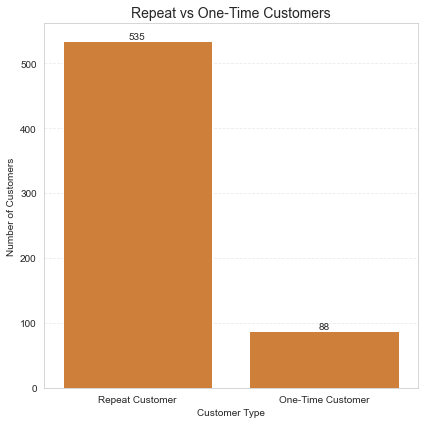

In [81]:
plt.figure(figsize=(6,6))

ax = sns.barplot(
    data=customer_summary,
    x="CustomerType",
    y="Count",
    color="#E67E22"
)

plt.title("Repeat vs One-Time Customers", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insights**
- The analysis shows that the majority of customers on the EduRead platform are repeat purchasers, indicating strong customer retention and continued engagement with the platform. Only a smaller portion of customers make a single purchase and do not return.
This pattern suggests that once customers experience the platform, they are likely to continue purchasing additional books or subscriptions

**Recommendation**
- EduRead should continue investing in strategies that encourage repeat purchases, such as personalized recommendations, loyalty incentives, and targeted promotions. Additionally, the company may benefit from identifying the characteristics of one-time purchasers in order to design campaigns that convert them into repeat customers

## Revenue Contribution by Customer Type

In [83]:
q_customer_value = """
SELECT
    fs.Student_SK,
    COUNT(DISTINCT fs.Order_BK) AS TotalOrders,
    SUM(fs.NetSalesAmount) AS TotalRevenue
FROM FactSales fs
GROUP BY fs.Student_SK
"""
with engine.connect() as conn:
    customer_value = pd.read_sql(text(q_customer_value), conn)
customer_value["CustomerType"] = customer_value["TotalOrders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)
customer_summary = customer_value.groupby("CustomerType").agg(
    Customers=("Student_SK","count"),
    TotalRevenue=("TotalRevenue","sum")
).reset_index()

customer_summary


,CustomerType,Customers,TotalRevenue
0,One-Time Customer,88,3254.99
1,Repeat Customer,535,72722.37


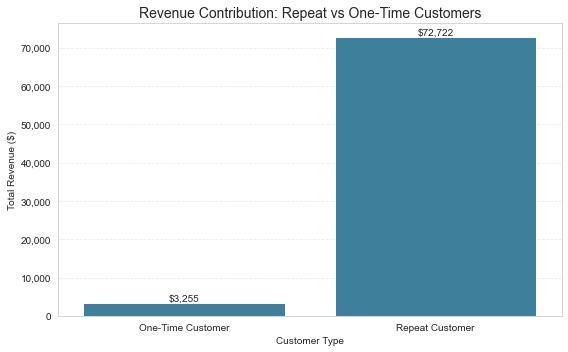

In [86]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=customer_summary,
    x="CustomerType",
    y="TotalRevenue",
    color="#2E86AB"
)

plt.title("Revenue Contribution: Repeat vs One-Time Customers", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue ($)")

# Format revenue axis
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:,.0f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom')

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insight**
- The analysis shows that repeat customers generate the overwhelming majority of total platform revenue, while one-time customers contribute only a small fraction. This indicates that long-term engagement with the platform is a major driver of financial performance.

**Recommendation**
- EduRead should continue investing in retention strategies such as personalized book recommendations, loyalty incentives, and targeted promotions that encourage repeat purchases. Additionally, the platform may benefit from identifying why some users only make a single purchase and implementing onboarding or follow-up campaigns designed to convert these customers into repeat buyers.

## Monthly Order Volume Trends

In [87]:
q_operations = """
SELECT
    dd.Year,
    dd.Quarter,
    dd.Month,
    COUNT(DISTINCT fs.Order_BK) AS TotalOrders,
    SUM(fs.NetSalesAmount) AS TotalRevenue
FROM FactSales fs
JOIN DimDate dd
    ON fs.SalesDate = dd.Date_SK
GROUP BY dd.Year, dd.Quarter, dd.Month
ORDER BY dd.Year, dd.Month
"""
with engine.connect() as conn:
    ops_data = pd.read_sql(text(q_operations), conn)

ops_data.head()

,Year,Quarter,Month,TotalOrders,TotalRevenue
0,2024,1,1,91,3162.58
1,2024,1,2,57,1991.45
2,2024,1,3,82,3145.94
3,2024,2,4,69,2453.21
4,2024,2,5,84,2779.22


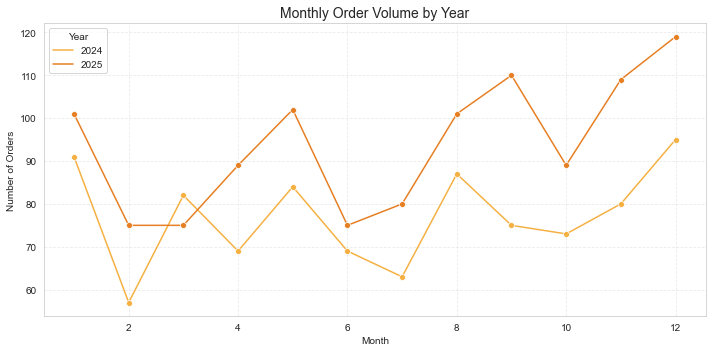

In [88]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=ops_data,
    x="Month",
    y="TotalOrders",
    hue="Year",
    marker="o",
    palette=["#F5B041", "#E67E22"]   # light orange for 2024, strong orange for 2025
)

plt.title("Monthly Order Volume by Year", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**Insights**
- Monthly order volume shows a consistent increase in platform activity in 2025 compared to 2024, with several months experiencing noticeably higher order counts. The data also indicates recurring seasonal fluctuations, with some months experiencing dips in activity followed by strong rebounds later in the year.

**Recommendation**
- EduRead should incorporate these seasonal demand patterns into operational planning, including content promotion schedules, platform capacity planning, and marketing campaigns. Preparing for higher order volumes during peak months can help ensure smooth platform performance and maximize revenue opportunities.

## Key Findings and Recommendations

1. **Platform Revenue and Orders Are Growing**

Finding:
- Both total revenue and order volume increased from 2024 to 2025, indicating that the EduRead platform is experiencing steady growth and increasing user engagement.

Recommendation:
- EduRead should continue investing in marketing campaigns and content expansion to sustain this growth trajectory. Monitoring monthly demand patterns can also help optimize promotional timing and inventory planning.

2. **A Small Number of Authors and Genres Drive Significant Revenue**

Finding:
- The analysis shows that a limited number of authors and genres contribute a substantial portion of total platform revenue, suggesting that certain types of content resonate strongly with users.

Recommendation:
- EduRead should strengthen partnerships with high-performing authors and publishers while prioritizing promotional efforts for popular genres. Expanding the catalog within these high-demand categories may further increase revenue.

3. **Traditional Card Payments Dominate Checkout Behavior**

Finding:
- Credit and debit cards represent the most frequently used payment methods and generate the highest share of revenue on the platform. Digital wallet options such as Apple Pay, PayPal, and Google Pay are used less frequently.

Recommendation:
- EduRead should maintain seamless integration with major card providers while exploring opportunities to increase adoption of digital wallet payments through mobile-friendly checkout experiences and promotional incentives.

4. **Repeat Customers Generate the Majority of Revenue**

Finding:
- Repeat customers account for the vast majority of platform revenue, highlighting the importance of customer retention in sustaining long-term business performance.

Recommendation:
- EduRead should focus on retention strategies such as personalized book recommendations, loyalty programs, and targeted email campaigns to encourage continued engagement and repeat purchases.

5. **Order Volume Shows Clear Seasonal Patterns**

Finding:
- Monthly order trends indicate fluctuations throughout the year, with certain months experiencing higher purchasing activity than others.

Recommendation:
- EduRead should align marketing campaigns, promotional offers, and platform capacity planning with these seasonal demand patterns to maximize revenue during peak purchasing periods.

**CONCLUSION**

The analysis of the EduRead Digital Library data mart reveals several important insights about the platform’s performance and customer behavior. Overall revenue and order volume increased from 2024 to 2025, indicating steady platform growth and rising user engagement. Seasonal trends in monthly revenue and order volume suggest that demand fluctuates throughout the year, highlighting opportunities for targeted marketing campaigns during peak purchasing periods.

Content performance analysis shows that a small group of authors and genres generate a large share of revenue, suggesting that strategic partnerships and focused promotion of high-performing content could further strengthen platform growth. Payment analysis indicates that traditional credit and debit card methods remain the most frequently used and highest revenue-generating payment options, though digital wallets represent an opportunity for future growth.

Finally, customer behavior analysis demonstrates that repeat customers generate the majority of platform revenue, underscoring the importance of retention strategies such as personalized recommendations, loyalty incentives, and customer engagement initiatives. Together, these findings provide actionable insights that can guide decision-making across leadership, finance, product, partnerships, and customer success teams as EduRead continues to scale its digital library platform